In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

What are the most demanded skills for the top 3 most popular data roles? 

How are in-demand skills trending for Data Analysts?

How well do jobs and skills pay for Data Analysts?

What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

In [67]:
df_us_da = df.loc[((df['job_country'] == 'United States') 
                  & 
                  (df['job_title_short'] == 'Data Analyst'))]

In [68]:
df_plot = df_us_da['job_location'].value_counts().head(20).to_frame()
#converted to data frame  
df_plot

,count
job_location,
Anywhere,5106
"New York, NY",3035
"Atlanta, GA",2741
"Chicago, IL",2337
"Austin, TX",1919
"Dallas, TX",1862
"Washington, DC",1592
"Charlotte, NC",1433
"Tampa, FL",1431


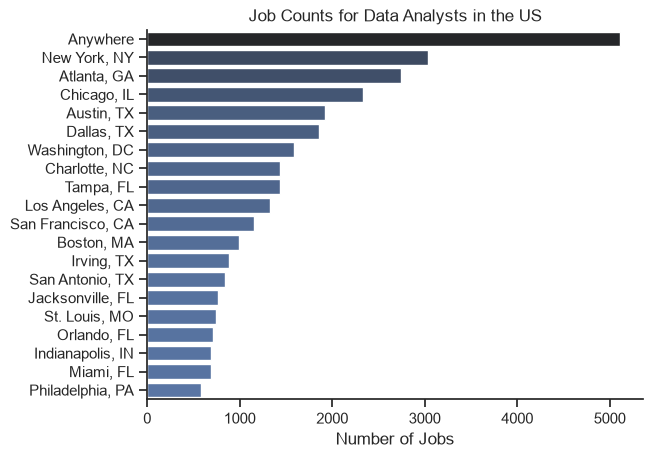

In [69]:
sns.set_theme(style='ticks')

sns.barplot(
    data=df_plot,
    y='job_location',
    x='count',
    hue='count',
    palette='dark:b_r',
    legend=False
)

sns.despine()

plt.title('Job Counts for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')

plt.show()

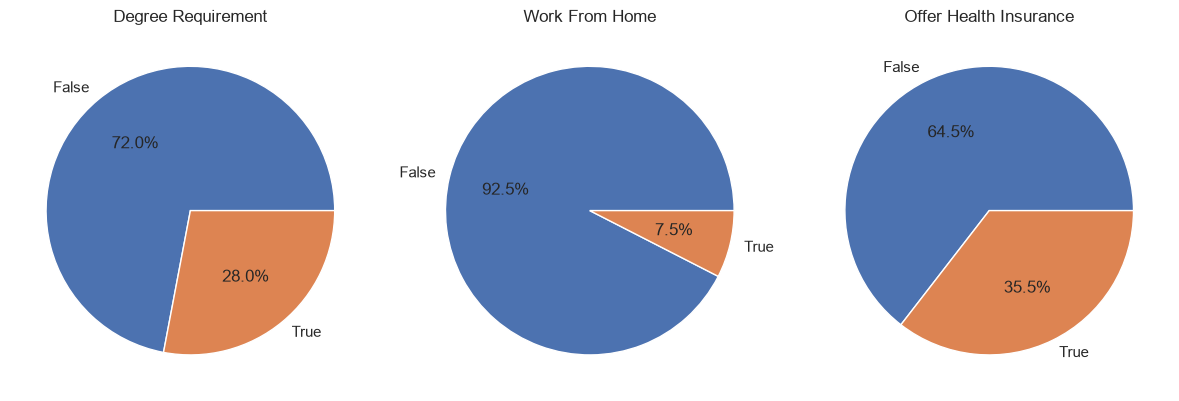

In [70]:
df_job_degree = df_us_da['job_no_degree_mention'].value_counts()
df_job_wfh = df_us_da['job_work_from_home'].value_counts()
df_job_insurance = df_us_da['job_health_insurance'].value_counts()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].pie(
    df_job_degree,
    labels=df_job_degree.index,
    autopct='%1.1f%%'
)
ax[0].set_title('Degree Requirement')

ax[1].pie(
    df_job_wfh,
    labels=df_job_wfh.index,
    autopct='%1.1f%%'
)
ax[1].set_title('Work From Home')

ax[2].pie(
    df_job_insurance,
    labels=df_job_insurance.index,
    autopct='%1.1f%%'
)
ax[2].set_title('Offer Health Insurance')

plt.tight_layout()
plt.show()
 

Text(0, 0.5, '')

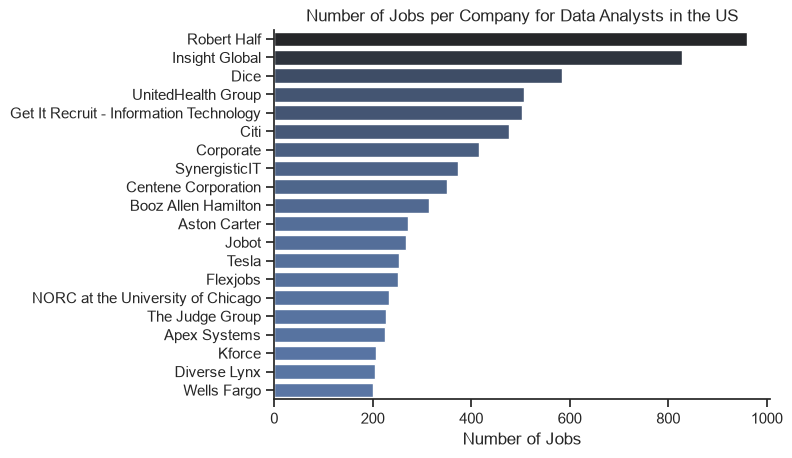

In [71]:
df_companies = df_us_da['company_name'].value_counts().head(20).to_frame()
#note when converting to data frame, the name of companies are index, can change it.
sns.barplot(x=df_companies['count'], y=df_companies.index, hue=df_companies['count'], palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')

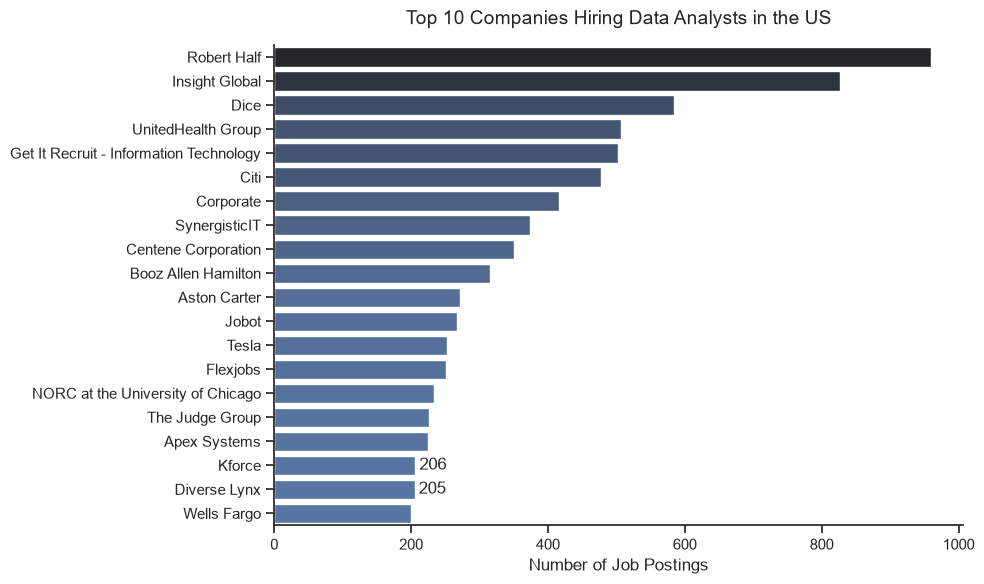

In [72]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=df_companies['count'],
    y=df_companies.index,
    hue=df_companies['count'],
    palette='dark:b_r',
    legend=False
)

sns.despine()

plt.title(
    'Top 10 Companies Hiring Data Analysts in the US',
    fontsize=14,
    pad=15
)

plt.xlabel('Number of Job Postings')
plt.ylabel('')

ax.bar_label(ax.containers[1], padding=3)
ax.bar_label(ax.containers[2], padding=3)

plt.tight_layout()
plt.show()

Text(0, 0.5, '')

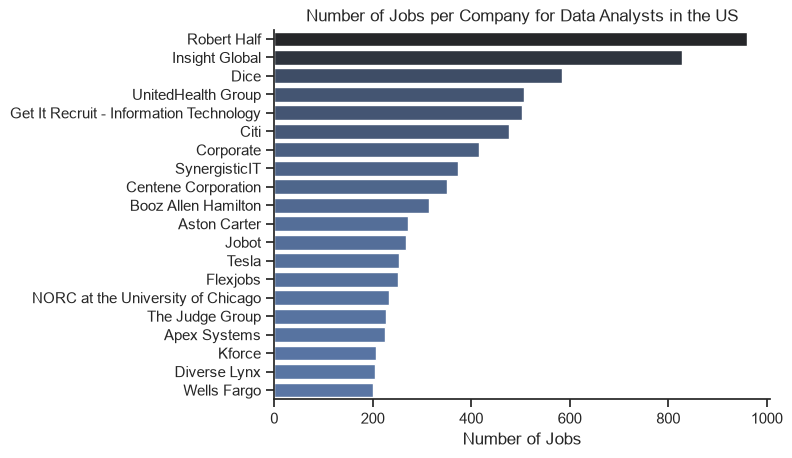

In [73]:
df_companies_reset = df_us_da['company_name'].value_counts().head(20).to_frame().reset_index()
sns.barplot(x=df_companies_reset['count'], y=df_companies_reset['company_name'], hue=df_companies['count'], palette='dark:b_r', legend=False)
sns.barplot(data = df_companies_reset, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')